# FORCE Level 2 processing using openEO on CDSE with external Query

### Purpose

The [Earth Observation Application Package (EOAP)](https://docs.ogc.org/bp/20-089r1.html) and surrounding tools implemented in the [`apex-force-openeo`](https://github.com/bcdev/apex-force-openeo) repository make it possible to use the [FORCE](https://force-eo.readthedocs.io/en/latest/) EO processing engine on the [Copernicus Data Space Ecosystem (CDSE)](https://dataspace.copernicus.eu/) using the [openEO](https://openeo.dataspace.copernicus.eu/) API.
This notebook uses `pystac_client` to make a STAC query to determine input products. This is a valid alternative to the `query_stac` process in OpenEO, especially until it is supported on the production environment.

> This notebook serves to showcase a simple workflow to run FORCE level 2 on CDSE and download the processed results.

Please note that this is neither a tutorial for FORCE nor for openEO, please have a look at the "Further Reading" section below, if you are unfamiliar with either. The basic openEO client operations will be explained, FORCE will be used without further explanation. Please refer to the [FORCE documentation for the level 2 processing system](https://force-eo.readthedocs.io/en/latest/components/lower-level/level2/) to learn more.


### Prerequisites

In order to run this notebook, you need to have a CDSE account and sufficient openEO credits to run the jobs. Please note that CDSE provides a contigent of free credits each month, so you should be able to run the notebook if you haven't used up your credits, with no actual cost.

> At the time of writing (2026-04-20) some of the openEO processes used require an account for the staging deployment of the openEO backend. However, they should be available on the production deployment soon.

### Content

1. Connect to OpenEO backend
2. Make a query to the CDSE STAC catalog to determine input products
3. Run the FORCE l2ps on CDSE using OpenEO and the FORCE EOAP
4. Download processed products
5. Visualize the results

### Citation and Acknowledgement

When using the FORCE processing engine, please make sure to properly [cite and acknowledge](https://force-eo.readthedocs.io/en/latest/policy/citation.html)
the software and its related [scientific publications](https://force-eo.readthedocs.io/en/latest/refs.html#refs).
The implementation as EOAP was performed in the context of ESA's [APEx](https://apex.esa.int/) initiative.

### Further reading

**APEx**

1. [Project website](https://apex.esa.int/)
2. [Documentation Portal](https://esa-apex.github.io/apex_documentation/)

**FORCE**

1. [Documentation](https://force-eo.readthedocs.io/en/latest/index.html)
1. [Level 2 processing system](https://force-eo.readthedocs.io/en/latest/components/lower-level/level2/)
1. [Citation and acknowledgement](https://force-eo.readthedocs.io/en/latest/policy/citation.html)


**openEO**

1. [openEO on CDSE](https://documentation.dataspace.copernicus.eu/APIs/openEO/openEO.html)
1. [Credit Usage on CDSE](https://documentation.dataspace.copernicus.eu/APIs/openEO/credit_usage.html)
1. [openEO project website](https://openeo.org/)
1. [openEO Python Client documentation](https://open-eo.github.io/openeo-python-client/)


### Imports

In [2]:
from pathlib import Path

import openeo
import contextily
import shapely
import pystac
import pystac_client
import matplotlib.pyplot as plt
import rioxarray

import force_example_utils as utils

### Area of Interest

For this example, we selected a small area around Modena on Italy's Adriatic Sea coast. 
Here, we quickly visualize the area of interest.

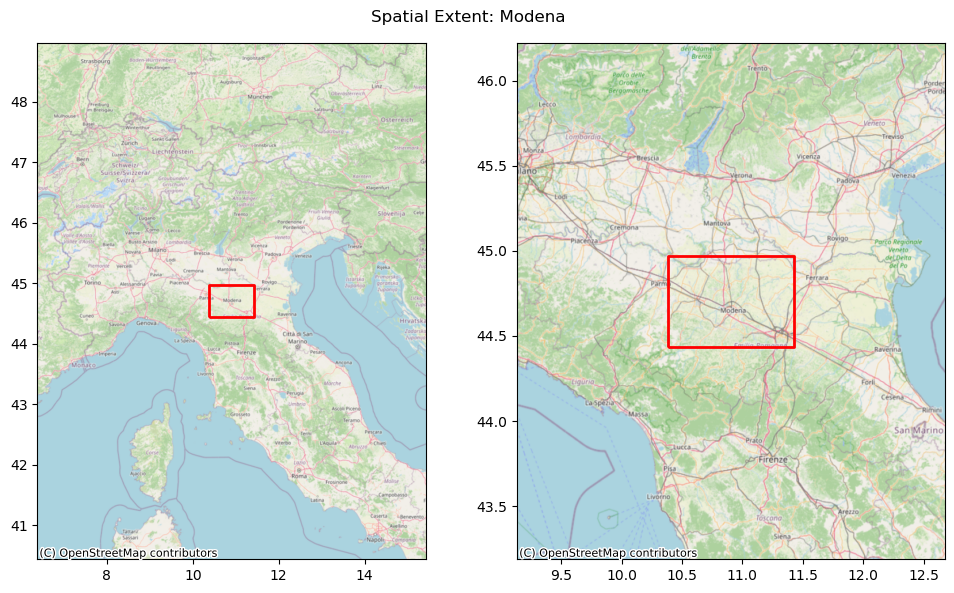

In [3]:
w,s,e,n = 10.386, 44.437, 11.423, 44.973
spatial_extent = { "west": w, "south": s, "east": e, "north": n}
aoi_name = "Modena"
temporal_extent=["2026-04-17", "2026-04-18"]

utils.plot_area_of_interest(
    w=w,
    s=s,
    e=e,
    n=n,
    large_context=4,
    figsize=(10, 6),
    title=f"Spatial Extent: {aoi_name}"
)

### Connect to the OpenEO backend

In order to send requests and start jobs on the openEO backend, we must first authenticate. If you haven't recently logged into the openEO backend, this cell will prompt you to log in. Please click the link produced in the cell to log in.

> If you don't have a CDSE account yet, please [create one first](https://documentation.dataspace.copernicus.eu/Registration.html).


> We are currently limited to the CDSE openEO staging environment. FORCE should be available in the production environment soon!

In [4]:
backend_url = "openeo-staging.dataspace.copernicus.eu"
connection = openeo.connect(backend_url).authenticate_oidc()

Authenticated using refresh token.


### Query the CDSE STAC catalog

To determine the inputs to process with FORCE, we need to determine a number of STAC Items, describing our input products. You can pass any `pystac.ItemCollection`, `pystac.Item`, `pystac.Collection` or `pystac.Catalog` to the process. Make sure that total input data is of reasonable size (e.g, avoid passing a STAC catalog of the Sentinel-2-L1C archive).

The easiest way to get an `ItemCollection` is to use `pystac_client.Client` and do a search:

In [5]:
L1C_COLLECTION_URL = "https://stac.dataspace.copernicus.eu/v1/collections/sentinel-2-l1c"

client = pystac_client.Client.open("https://stac.dataspace.copernicus.eu/v1")
search = client.search(
    datetime=temporal_extent, # note that openEO end-exclusive ranges and pystac_client includes the end by default. In this case, there should be no difference.
    max_items=2,
    collections=["sentinel-2-l1c"],
    bbox=[w, s, e, n]
)
item_collection = search.item_collection()

print("Found items:")
for item in search.items():
    print(item.id)


Found items:
S2A_MSIL1C_20260419T100711_N0512_R022_T32TPQ_20260419T152521
S2A_MSIL1C_20260419T100711_N0512_R022_T32TNQ_20260419T152521


### Running FORCE level 2 (l2ps)

Now that we have selected the input files, we can pass the selection to the FORCE level 2 process. The process will automatically download the necessary files to the executor on the CDSE infrastructure.

#### Note:

> **You will be able to use a dedicated process `force_level2` instead of `run_cwl_to_stac` which will make it unnecessary to explicitly pass the CWL document in the future.
Until this process is available on the CDSE openEO backend, `run_cwl_to_stac` can be used as shown here**.

#### Observing the progress on openEO

You can track the progress of your job by logging into the [openEO web interface](https://openeo.dataspace.copernicus.eu/)

Alternatively, in a separate Python shell / notebook, you can run the following snippet to get access to the logs as a Python list.
You can find out the job id from the next cell below.

Please be aware that the output from CWL jobs is not optimally rendered by openEO logs, so the logs may look a little bit messy and fragmented. However, they can be a valuable source of information to debug issues.

```Python
JOB_ID = ... # see the output from `l2_job.start_and_wait()` below)
connection = ... # connect to the same backend
l2_job = connection.job(JOB_ID)
l2_logs = l2_job.logs()
print("\n".join(l2_logs[:20])) # show the first 20 logs.
l2_logs # openEO logs have rich rendering and a searchable interface in jupyter notebooks
```

#### How does the openEO code work?

First, we load the [Common Workflow Language (CWL)](https://www.commonwl.org/) document `force-level2.cwl` as a string and pass it to openEO. This CWL document is an EOAP, together with the docker image referenced within it.
In the CWL, the inputs, outputs and steps of the FORCE level 2 workflow are specified. Simplified, these steps are:

1. `staging` Download the inputs defined by the query results
2. `force_level2` Run FORCE level 2 and create STAC metadata for it

> Once the FORCE custom process is available, it will no longer be necessary to specify the CWL document, as the process will know which one to use. For now, we have to use the generic `run_cwl_to_stac` process.
We create a StacResource

#### Parametrization

Most parameters of FORCE level 2 are supported and can be passed to the `context` dictionary (passed to the `run_cwl_to_stac` process below).
For the upcomming FORCE level 2 process, parameters can be passed directly (without wrapping them into a `context` dictionary.
It will look similar to this:

```Python
stac_resource = openeo.rest.stac_resource.StacResource(
    graph=openeo.internal.graph_building.PGNode(
        process_id="force_level2",
        arguments={
            do_brdf=True,
            output_ovv=False,
            # ...
            
        }
    ),
    connection=connection,
)
```

Note that the parameters have the same name as in the FORCE parameter file, but in `lower_snake_case` to conform with openEO convention. 

> The EOAP supports most parameters that can be specified in the parameter file with a few exceptions:
> - Parameters that set input/output directories, these are managed by the EOAP
> - Parameters that specify processing details, e.g., `NPROC`
> - Only the `Copernicus_30m` digital elevation model is supported (parameter `DEM`/`dem`)



In [6]:
cwl_text = Path("force-level2.cwl").read_text()
context = dict(
    stac_document=item_collection.to_dict(),
    do_brdf=True,
    output_ovv=True,
    # ...
)

stac_resource = openeo.rest.stac_resource.StacResource(
    graph=openeo.internal.graph_building.PGNode(
        process_id="run_cwl_to_stac",
        arguments={
            "cwl": cwl_text,
            "context": context,
        }
    ),
    connection=connection,
)
l2_job = stac_resource.create_job(title=f"FORCE level 2 - {aoi_name}")
print(f"Job id: '{l2_job.job_id}'")
l2_job.start_and_wait()

Job id: 'j-260420145611423a961c16b95d97a26c'
0:00:00 Job 'j-260420145611423a961c16b95d97a26c': send 'start'
0:00:14 Job 'j-260420145611423a961c16b95d97a26c': created (progress 0%)
0:00:19 Job 'j-260420145611423a961c16b95d97a26c': created (progress 0%)
0:00:26 Job 'j-260420145611423a961c16b95d97a26c': created (progress 0%)
0:00:34 Job 'j-260420145611423a961c16b95d97a26c': created (progress 0%)
0:00:44 Job 'j-260420145611423a961c16b95d97a26c': created (progress 0%)
0:00:57 Job 'j-260420145611423a961c16b95d97a26c': created (progress 0%)
0:01:12 Job 'j-260420145611423a961c16b95d97a26c': running (progress 10.4%)
0:01:32 Job 'j-260420145611423a961c16b95d97a26c': running (progress 13.0%)
0:01:56 Job 'j-260420145611423a961c16b95d97a26c': running (progress 15.9%)
0:02:26 Job 'j-260420145611423a961c16b95d97a26c': running (progress 19.3%)
0:03:05 Job 'j-260420145611423a961c16b95d97a26c': running (progress 23.3%)
0:03:52 Job 'j-260420145611423a961c16b95d97a26c': running (progress 27.7%)
0:04:50 Jo

<BatchJob job_id='j-260420145611423a961c16b95d97a26c'>

## Download the results

Assets from the completed processing can be downloaded using openEO's [`get_results`](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.job.BatchJob.get_results) and [`download_files`](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.job.JobResults.download_files) methods. The FORCE directory structure will automatically be respected. After executing the `download_files` process, check the `force-level2-assets` (or the name you specified) directory next to this notebook for the results.
If you want to download only partial results, you can use the [`download_file`](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.job.JobResults.download_file) (singular) process instead.

In [8]:
l2_results = l2_job.get_results()
l2_results

<JobResults for job 'j-260420145611423a961c16b95d97a26c'>

In [11]:
assets_path = Path("force-l2-assets-pystac-client")
l2_results.download_files(assets_path)

[PosixPath('force-l2-assets-pystac-client/europe/X0031_Y0029/20260419_LEVEL2_SEN2A_BOA.tif'),
 PosixPath('force-l2-assets-pystac-client/europe/X0031_Y0029/20260419_LEVEL2_SEN2A_OVV.jpg'),
 PosixPath('force-l2-assets-pystac-client/europe/X0031_Y0029/20260419_LEVEL2_SEN2A_QAI.tif'),
 PosixPath('force-l2-assets-pystac-client/europe/datacube-definition.prj'),
 PosixPath('force-l2-assets-pystac-client/job-results.json')]

### Visualize

Now that we have downloaded the results, we may continue the analysis of the data as usual. As a small example, we generate an RGB of the results:

In [19]:
X, Y = "0031", "0029"
tiff_path = assets_path / "europe" / f"X{X}_Y{Y}" / "20260419_LEVEL2_SEN2A_BOA.tif"
ds = rioxarray.open_rasterio(tiff_path, masked=True)
ds.load()
ds.close()

rgb_da = ds.isel(band=slice(0,3))
rbg_da = rgb_da.transpose() # to order the data in R,G,B (not B, G, R, FORCE default)
rgb_da

<xarray.DataArray (band: 3, y: 7500, x: 7500)> Size: 675MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * band         (band) int64 24B 1 2 3
  * x            (x) float64 60kB -8.556e+05 -8.555e+05 ... -7.056e+05
  * y            (y) float64 60kB -1.004e+06 -1.004e+06 ... -1.154e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('BLUE', 'GREEN', 'RED', 'REDEDGE1', 'REDEDGE2', 'REDEDGE...

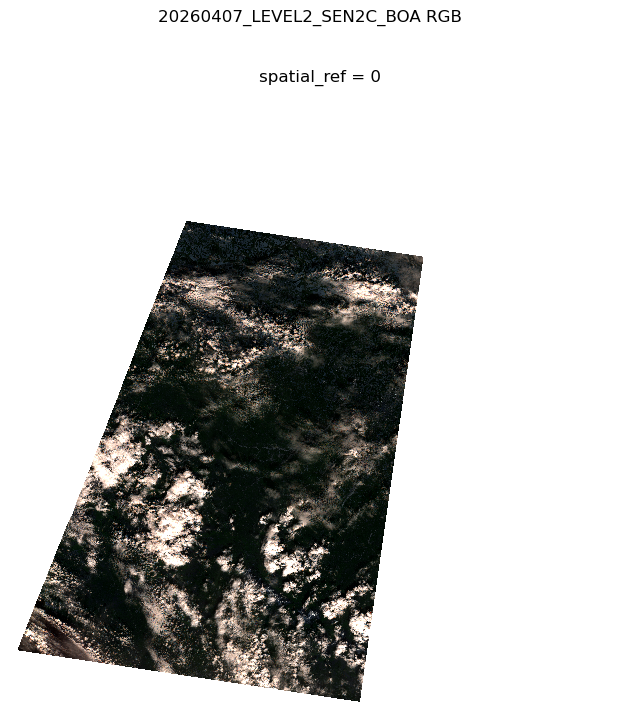

In [21]:
if fig:
    plt.close(fig)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
rgb_da.plot.imshow(ax=ax, rgb="band", robust=True)
ax.axis("off")
fig.suptitle("20260407_LEVEL2_SEN2C_BOA RGB");